# Customer Churn — Data Understanding & EDA

## Objective

The objective of this analysis is to understand customer characteristics,
identify data-quality issues, discover factors associated with churn,
and generate business hypotheses that will guide preprocessing,
feature engineering, and model development.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, pointbiserialr

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
DATA_PATH = r"../data/raw/customer_churn_2026.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customer_id,age,service_segment,signup_channel,primary_device,tenure_months,contract_type,plan_tier,num_services,has_family_plan,monthly_charges,total_charges,payment_method,auto_pay,payment_failures_last_year,support_tickets_last_year,avg_resolution_hours,uses_mobile_app,app_logins_per_month,avg_session_minutes,monthly_usage_hours,days_since_last_login,email_open_rate_pct,satisfaction_score,nps_score,competitor_offer_received,price_increase_last_year_pct,discount_offered,discount_pct,referrals_made,churn
0,CX00001,37,Streaming,Referral,Mobile,16,Month-to-month,Premium,6,False,29.41,468.65,Bank transfer,False,3,3,7.80,True,25,30.10,12.50,25,35.70,9.60,10,False,7.10,True,8.70,0,Yes
1,CX00002,28,Cloud Storage,Paid Social,Desktop,12,Annual,Plus,6,True,32.37,375.95,Digital wallet,True,0,3,20.60,True,18,8.40,2.50,6,55.60,6.90,8,True,0.90,True,10.30,1,No
2,CX00003,49,Productivity,Organic Search,Tablet,4,Month-to-month,Standard,1,False,16.31,63.64,Credit card,True,0,7,8.80,False,4,26.10,1.70,3,50.70,6.70,7,False,5.70,True,19.70,0,No
3,CX00004,42,Fintech,Email Campaign,Desktop,10,Month-to-month,Plus,8,False,52.26,484.55,Digital wallet,True,0,6,6.00,False,11,12.40,2.30,28,39.60,7.70,9,False,2.70,False,0.00,1,Yes
4,CX00005,30,Fintech,Organic Search,Mobile,14,Month-to-month,Basic,1,True,6.58,81.40,Debit card,False,4,2,26.20,True,22,16.40,6.00,5,62.30,6.50,9,False,2.20,False,0.00,0,Yes


In [3]:
df.shape

(5000, 31)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5000 non-null   str    
 1   age                           5000 non-null   int64  
 2   service_segment               5000 non-null   str    
 3   signup_channel                5000 non-null   str    
 4   primary_device                5000 non-null   str    
 5   tenure_months                 5000 non-null   int64  
 6   contract_type                 5000 non-null   str    
 7   plan_tier                     5000 non-null   str    
 8   num_services                  5000 non-null   int64  
 9   has_family_plan               5000 non-null   bool   
 10  monthly_charges               5000 non-null   float64
 11  total_charges                 5000 non-null   float64
 12  payment_method                5000 non-null   str    
 13  auto_pay      

In [5]:
df.dtypes.value_counts()

int64      9
float64    9
str        8
bool       5
Name: count, dtype: int64

In [6]:
df.columns.tolist()


['customer_id',
 'age',
 'service_segment',
 'signup_channel',
 'primary_device',
 'tenure_months',
 'contract_type',
 'plan_tier',
 'num_services',
 'has_family_plan',
 'monthly_charges',
 'total_charges',
 'payment_method',
 'auto_pay',
 'payment_failures_last_year',
 'support_tickets_last_year',
 'avg_resolution_hours',
 'uses_mobile_app',
 'app_logins_per_month',
 'avg_session_minutes',
 'monthly_usage_hours',
 'days_since_last_login',
 'email_open_rate_pct',
 'satisfaction_score',
 'nps_score',
 'competitor_offer_received',
 'price_increase_last_year_pct',
 'discount_offered',
 'discount_pct',
 'referrals_made',
 'churn']

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,CX00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.00,NaN,NaN,NaN,36.38,11.12,18.00,28.00,36.00,44.00,78.00
service_segment,5000,7,Streaming,1273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_channel,5000,6,Organic Search,1270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_device,5000,4,Mobile,2790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,5000.00,NaN,NaN,NaN,21.03,15.15,1.00,10.00,18.00,29.00,84.00
contract_type,5000,3,Month-to-month,2707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_tier,5000,4,Standard,1702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_services,5000.00,NaN,NaN,NaN,3.19,1.70,1.00,2.00,3.00,4.00,8.00
has_family_plan,5000,2,False,3793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Finding the Missing values and Duplicates:


In [8]:
missing=(
    df.isnull().sum().sort_values(ascending=0)
)
missing[missing>0]


Series([], dtype: int64)

In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


## Churn Distribution


In [10]:
df["churn_binary"] = df["churn"].map({
    "No": 0,
    "Yes": 1
})

In [11]:
df["churn"].value_counts()

churn
No     3915
Yes    1085
Name: count, dtype: int64

In [12]:
churn_distribution = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_distribution

churn
No    78.30
Yes   21.70
Name: proportion, dtype: float64

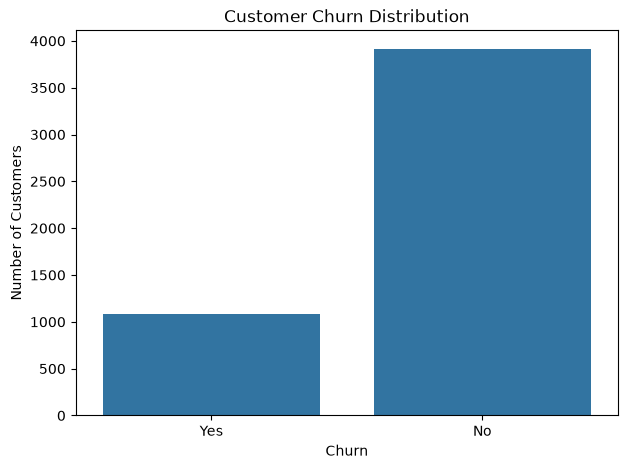

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
def churn_rate_by_category(data, column, target="churn"):
    result = (
        data.groupby(column)[target]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )

    return result

In [15]:
categorical_columns = df.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

categorical_columns

C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_48308\1935405765.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


['customer_id',
 'service_segment',
 'signup_channel',
 'primary_device',
 'contract_type',
 'plan_tier',
 'has_family_plan',
 'payment_method',
 'auto_pay',
 'uses_mobile_app',
 'competitor_offer_received',
 'discount_offered',
 'churn']

In [16]:
categorical_columns.remove("churn")
categorical_columns.remove("customer_id")

In [17]:
for column in categorical_columns:
    print(f"\n===== {column} =====")
    display(churn_rate_by_category(df, column))


===== service_segment =====


,service_segment,churn_rate
0,Fintech,22.86
1,Fitness,22.73
2,News & Media,22.39
3,Streaming,22.15
4,Productivity,21.40
5,Gaming,19.38
6,Cloud Storage,19.38



===== signup_channel =====


,signup_channel,churn_rate
0,Influencer,23.80
1,Referral,22.77
2,Paid Social,22.58
3,App Store,21.52
4,Organic Search,20.79
5,Email Campaign,17.88



===== primary_device =====


...

,uses_mobile_app,churn_rate
0,False,26.35
1,True,20.48



===== competitor_offer_received =====


,competitor_offer_received,churn_rate
0,True,28.15
1,False,17.70



===== discount_offered =====


,discount_offered,churn_rate
0,False,22.17
1,True,20.42


In [18]:
def plot_churn_by_category(data, column, target="churn"):
    rates = (
        data.groupby(column)[target]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))

    rates.plot(kind="bar")

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

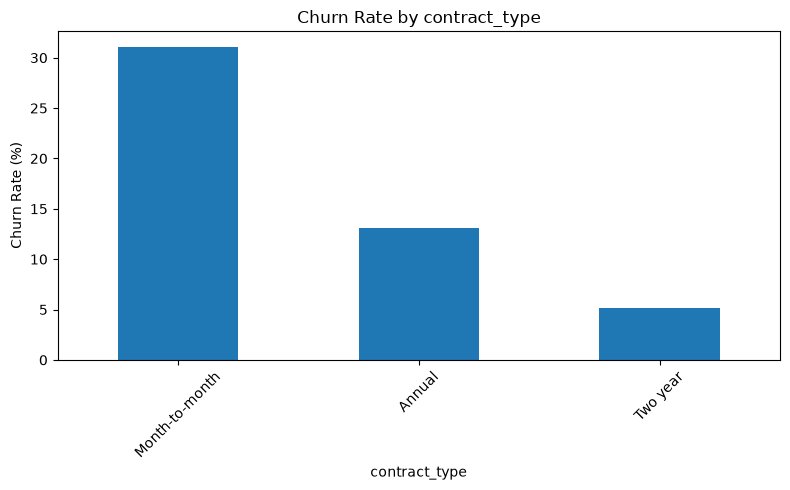

In [19]:
plot_churn_by_category(df, "contract_type")

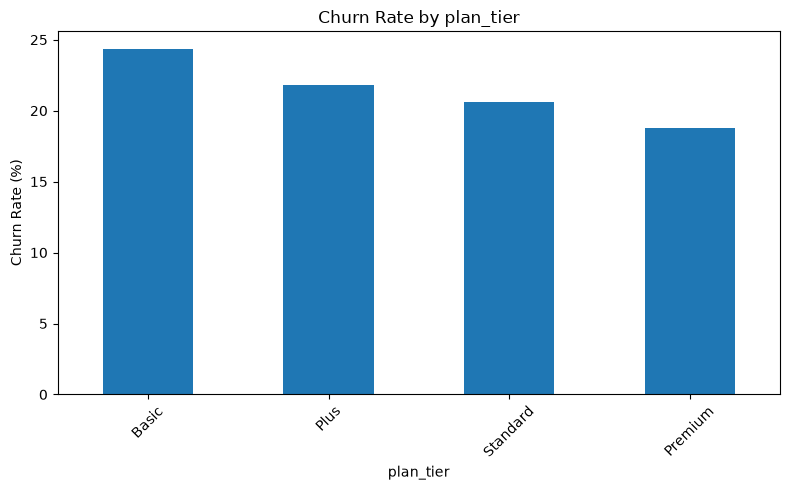

In [20]:
plot_churn_by_category(df, "plan_tier")

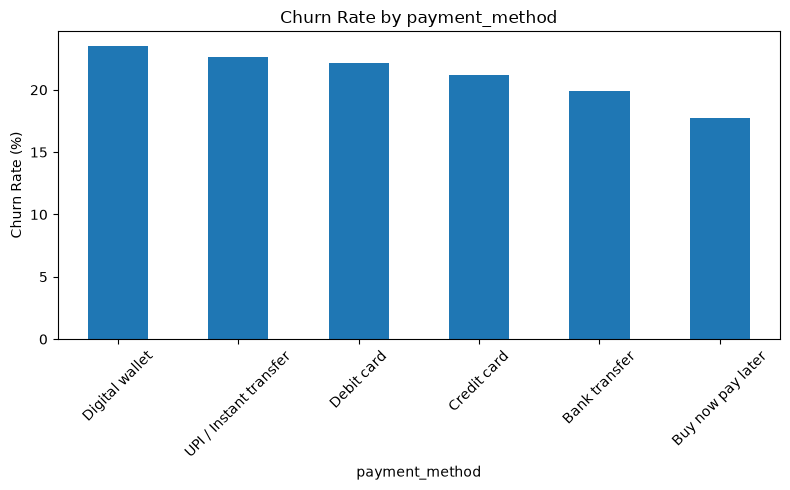

In [21]:
plot_churn_by_category(df, "payment_method")

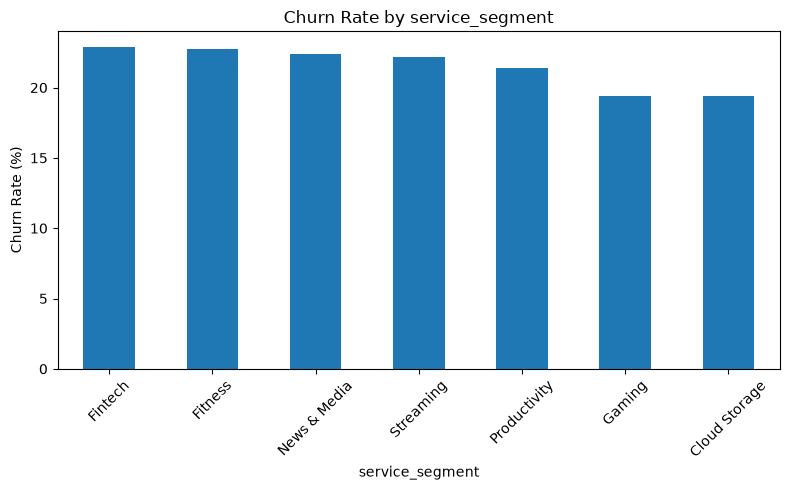

In [22]:
plot_churn_by_category(df, "service_segment")

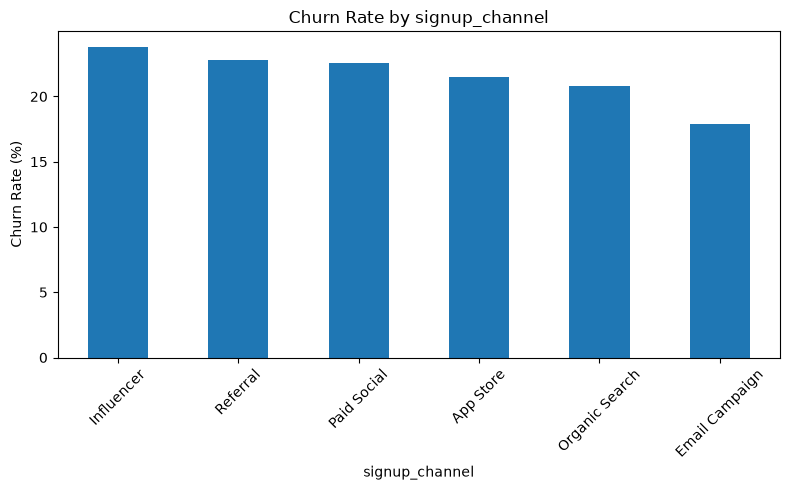

In [23]:
plot_churn_by_category(df, "signup_channel")

## Numerical Analysis


In [24]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns

['age',
 'tenure_months',
 'num_services',
 'monthly_charges',
 'total_charges',
 'payment_failures_last_year',
 'support_tickets_last_year',
 'avg_resolution_hours',
 'app_logins_per_month',
 'avg_session_minutes',
 'monthly_usage_hours',
 'days_since_last_login',
 'email_open_rate_pct',
 'satisfaction_score',
 'nps_score',
 'price_increase_last_year_pct',
 'discount_pct',
 'referrals_made',
 'churn_binary']

In [25]:
numerical_features = [
    col for col in numerical_columns
    if col != "churn_binary"
]
numerical_churn_summary = (
    df.groupby("churn")[numerical_features]
    .mean()
    .T
)

numerical_churn_summary

churn,No,Yes
age,36.33,36.57
tenure_months,22.29,16.50
num_services,3.19,3.19
monthly_charges,21.06,20.32
total_charges,440.85,317.85
payment_failures_last_year,0.61,0.80
support_tickets_last_year,2.29,2.66
avg_resolution_hours,11.47,13.35
app_logins_per_month,16.32,15.33
avg_session_minutes,14.42,14.53


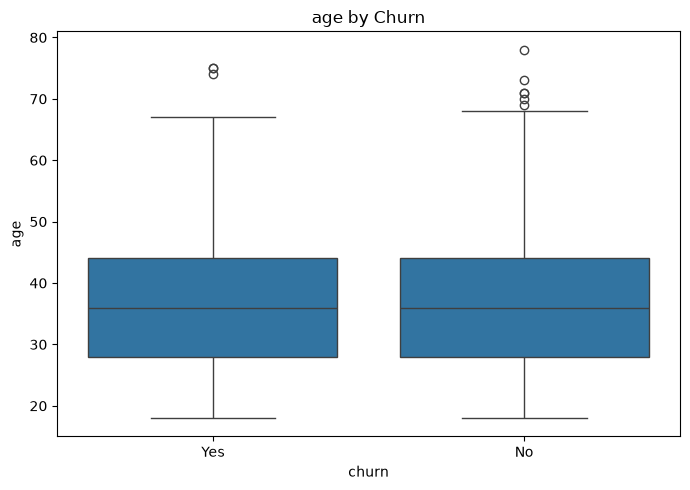

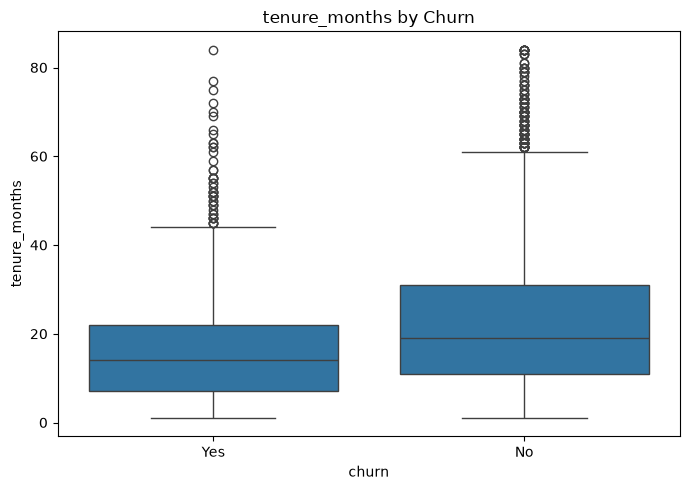

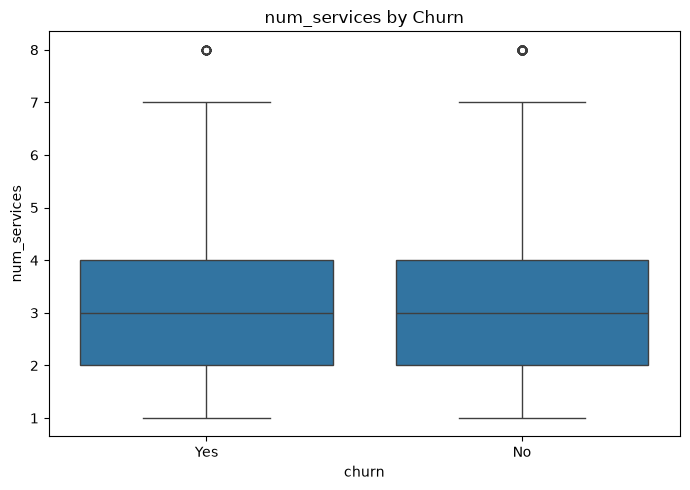

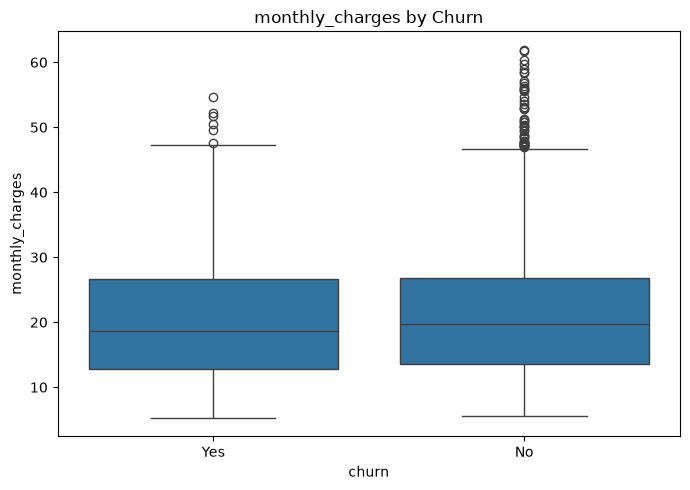

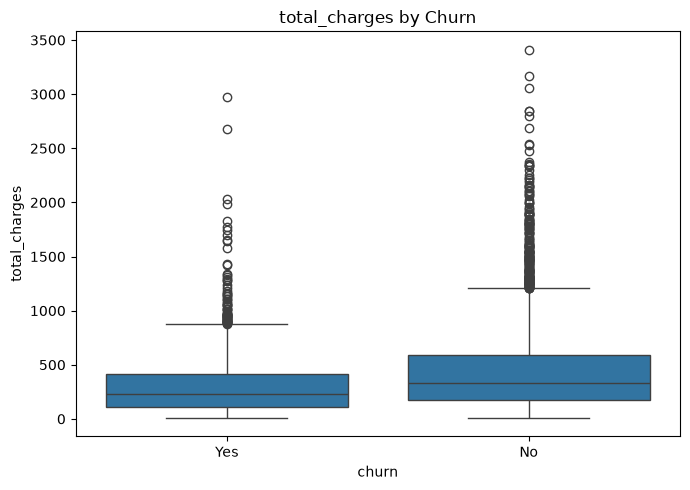

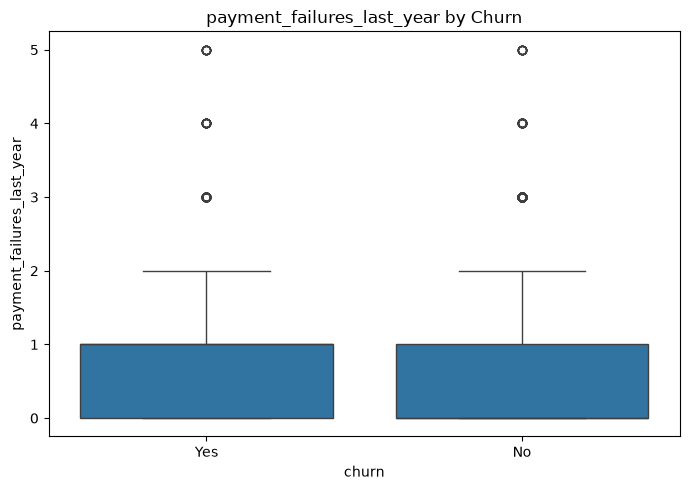

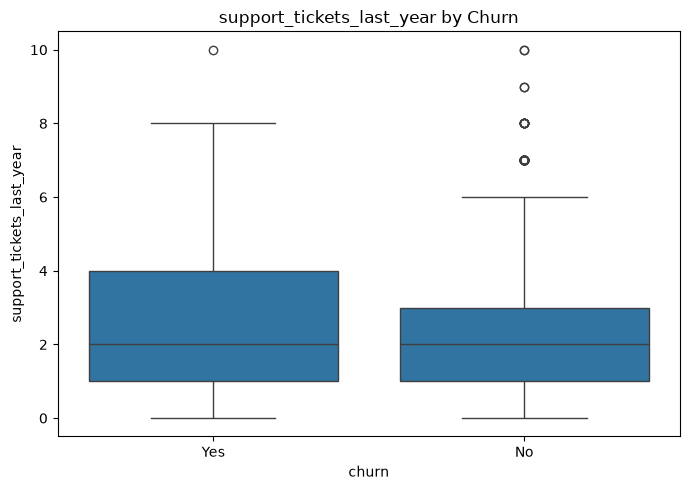

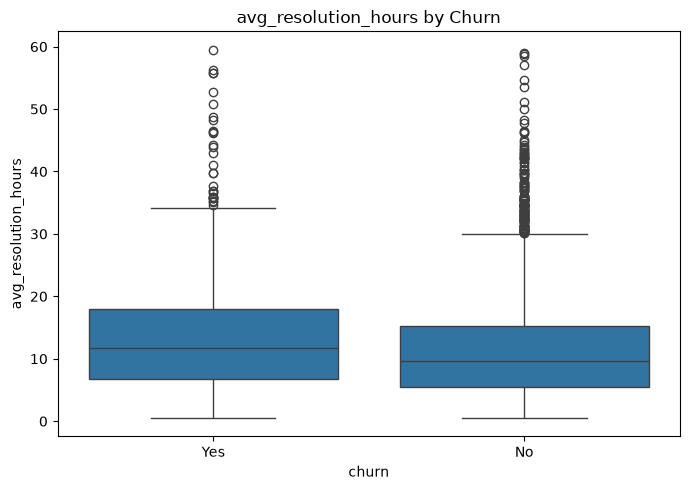

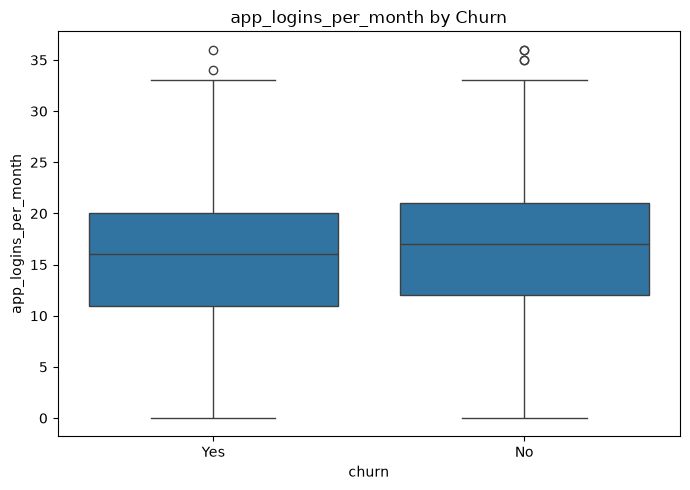

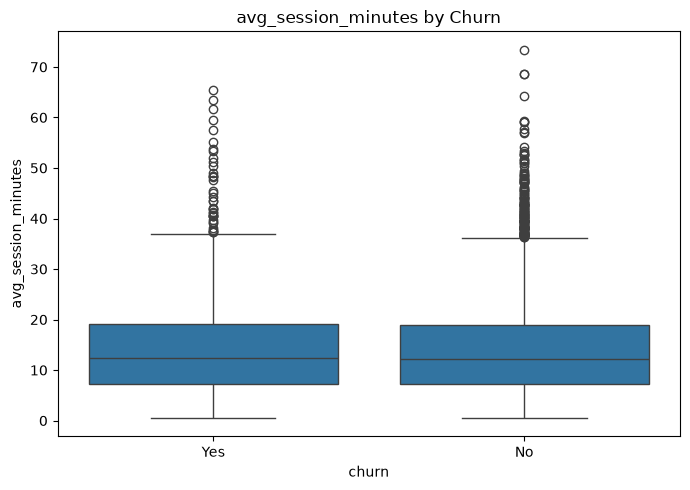

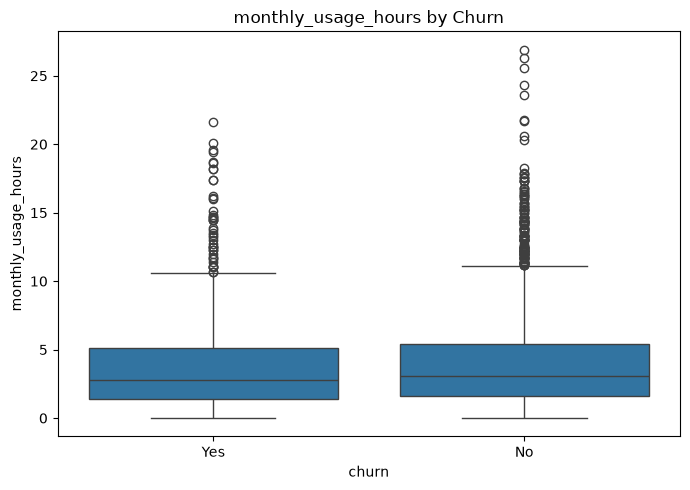

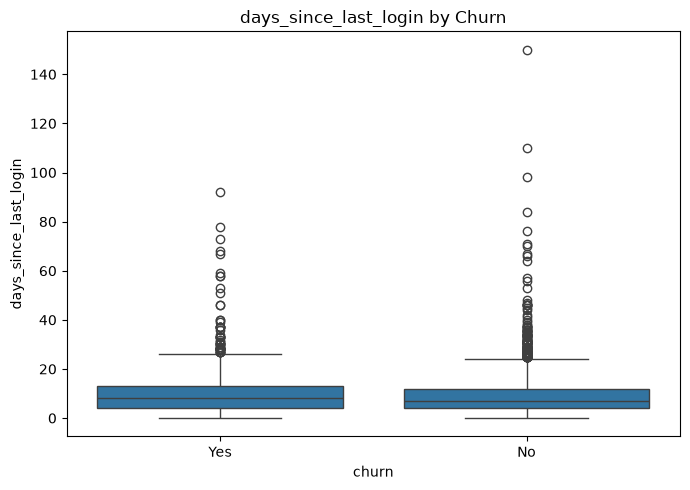

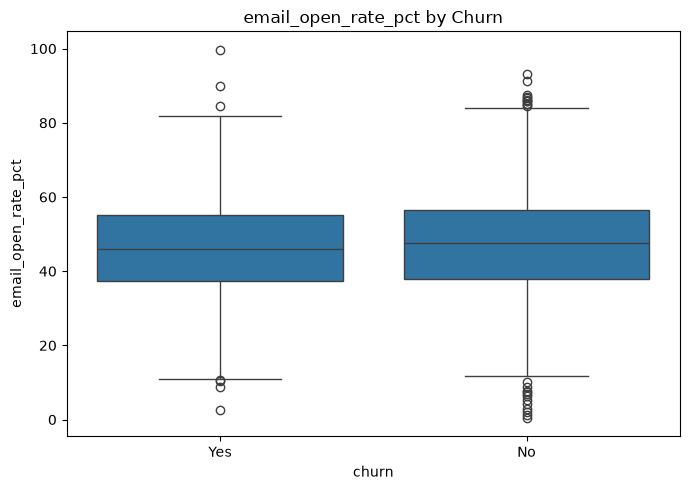

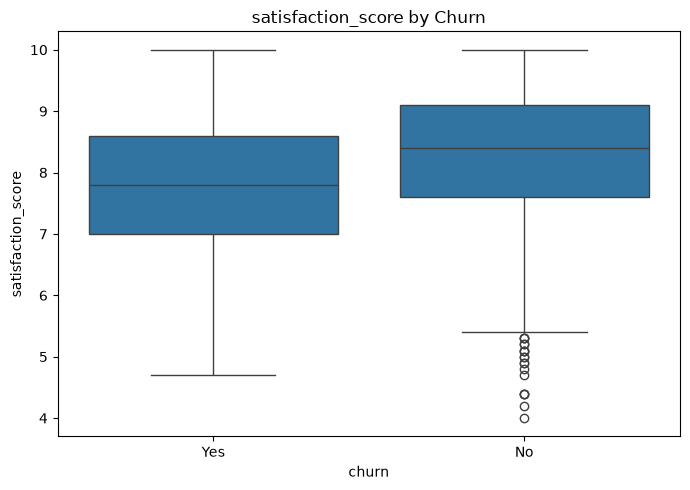

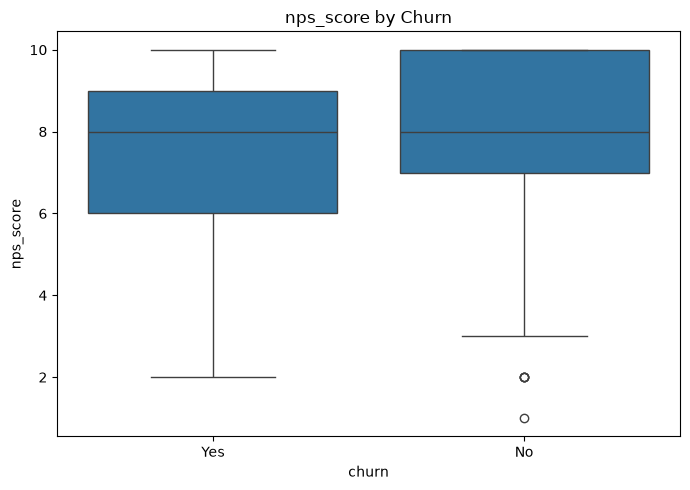

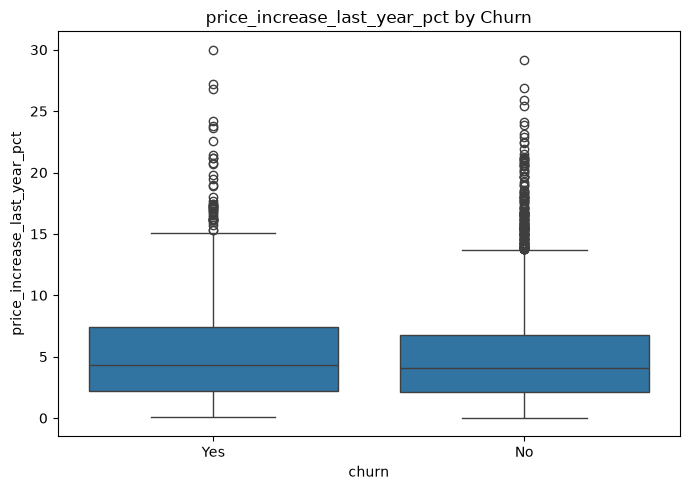

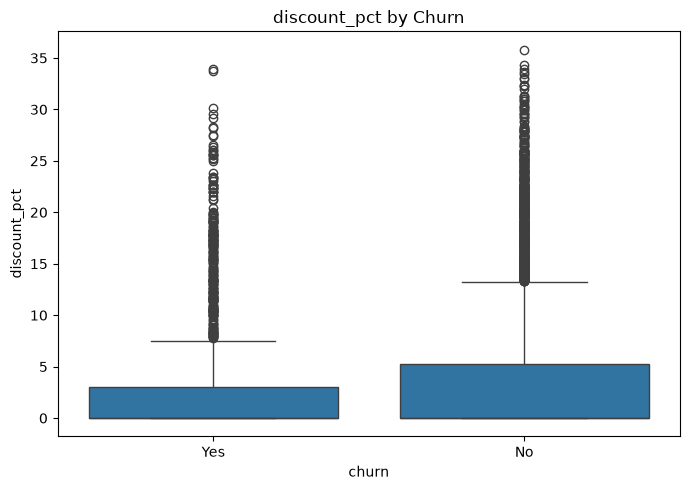

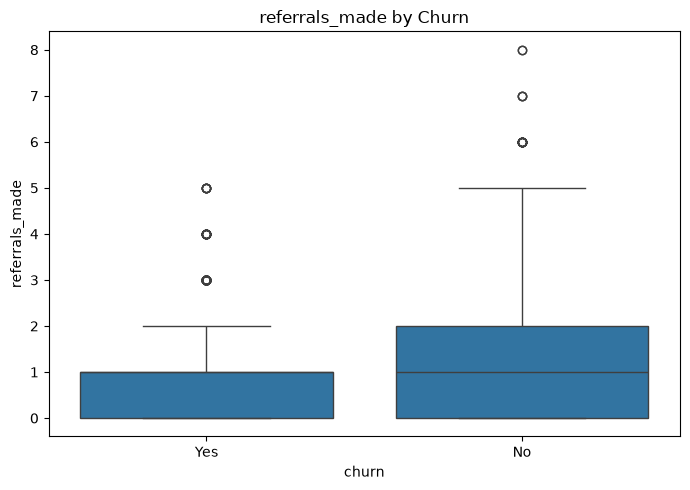

In [26]:
for column in numerical_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="churn",
        y=column
    )

    plt.title(f"{column} by Churn")
    plt.tight_layout()
    plt.show()

In [27]:
correlation_with_churn = (
    df[numerical_features + ["churn_binary"]]
    .corr()["churn_binary"]
    .drop("churn_binary")
    .sort_values()
)

correlation_with_churn

satisfaction_score             -0.20
tenure_months                  -0.16
nps_score                      -0.15
referrals_made                 -0.14
total_charges                  -0.13
app_logins_per_month           -0.06
discount_pct                   -0.04
monthly_charges                -0.03
email_open_rate_pct            -0.03
monthly_usage_hours            -0.02
num_services                   -0.00
avg_session_minutes             0.00
age                             0.01
days_since_last_login           0.04
price_increase_last_year_pct    0.04
payment_failures_last_year      0.09
avg_resolution_hours            0.09
support_tickets_last_year       0.09
Name: churn_binary, dtype: float64

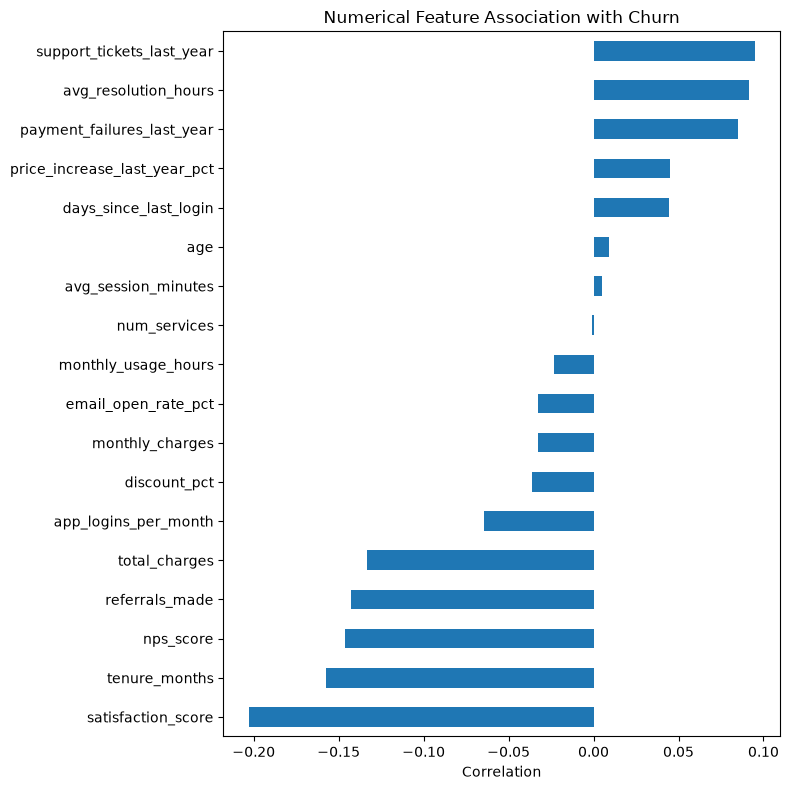

In [28]:
plt.figure(figsize=(8, 8))

correlation_with_churn.plot(
    kind="barh"
)

plt.title("Numerical Feature Association with Churn")
plt.xlabel("Correlation")

plt.tight_layout()
plt.show()

In [29]:
contract_churn = pd.crosstab(
    df["contract_type"],
    df["churn"],
    normalize="index"
) * 100

contract_churn

churn,No,Yes
contract_type,,
Annual,86.94,13.06
Month-to-month,68.93,31.07
Two year,94.86,5.14


In [30]:
contract_churn["Yes"].sort_values(ascending=False)

contract_type
Month-to-month   31.07
Annual           13.06
Two year          5.14
Name: Yes, dtype: float64

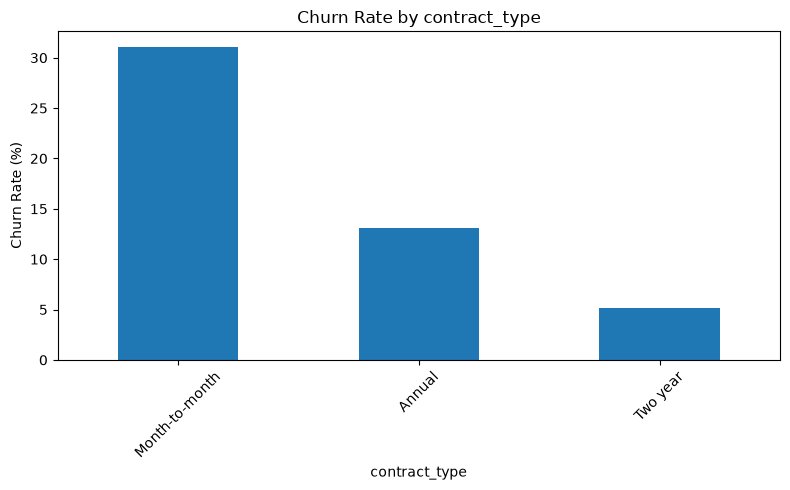

In [31]:
plot_churn_by_category(
    df,
    "contract_type"
)

### Finding — Contract Type

Churn varies substantially by contract type. Month-to-month customers
show considerably higher churn than annual and two-year customers.

This suggests that contract commitment is an important predictor of
customer retention.

This is an association rather than evidence of causality. Further
analysis is required to determine whether the relationship remains
after accounting for tenure, plan tier, charges, and customer
engagement.

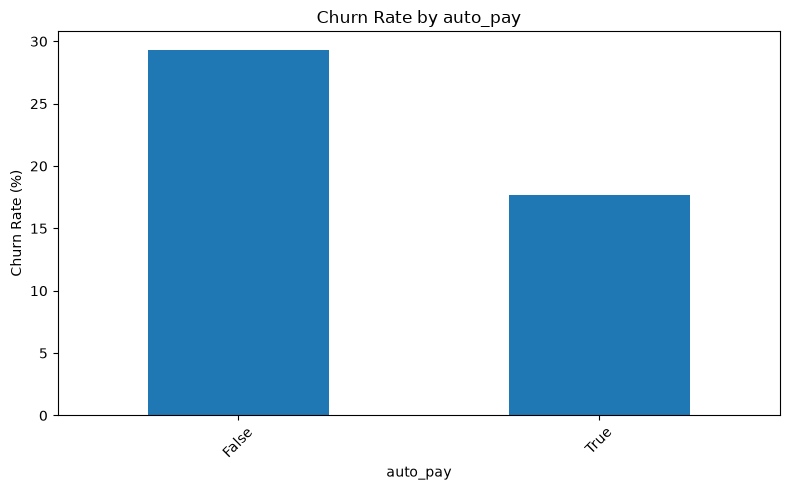

In [32]:
plot_churn_by_category(
    df,
    "auto_pay"
)

In [33]:
payment_failure_summary = (
    df.groupby("churn")["payment_failures_last_year"]
    .agg(["mean", "median"])
)

payment_failure_summary

,mean,median
churn,,
No,0.61,0.00
Yes,0.80,1.00


### Finding — Payment Friction

Customers with greater payment friction appear to have higher churn.
Auto-pay status and payment failures are therefore candidate predictive
features.

These variables may represent payment difficulty or subscription
maintenance friction and should be investigated further during feature
engineering.

In [34]:
df.groupby("churn")[
    [
        "satisfaction_score",
        "nps_score"
    ]
].agg(["mean", "median"])

satisfaction_score        nps_score       
                    mean median      mean median
churn                                           
No                  8.32   8.40      8.15   8.00
Yes                 7.77   7.80      7.56   8.00

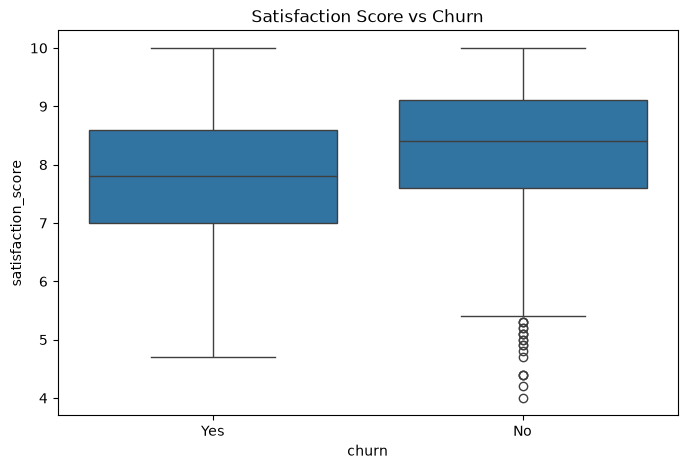

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="satisfaction_score"
)

plt.title("Satisfaction Score vs Churn")
plt.show()

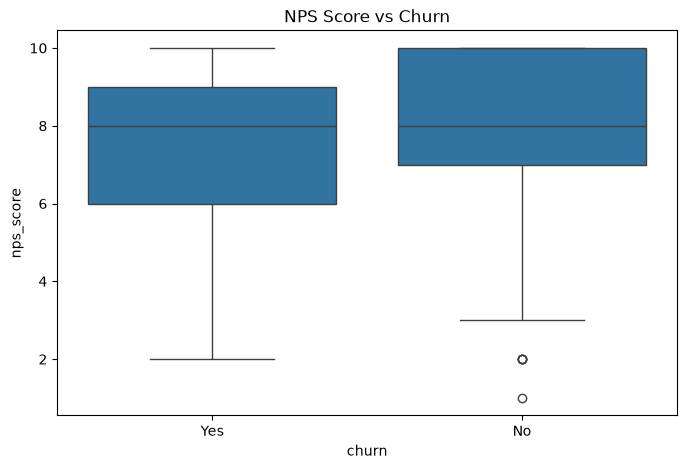

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="nps_score"
)

plt.title("NPS Score vs Churn")
plt.show()

### Finding — Customer Sentiment

Satisfaction and NPS show negative associations with churn.
Customers with stronger satisfaction and advocacy scores generally
appear less likely to churn.

These variables are strong candidates for the predictive model and
for customer-risk segmentation.

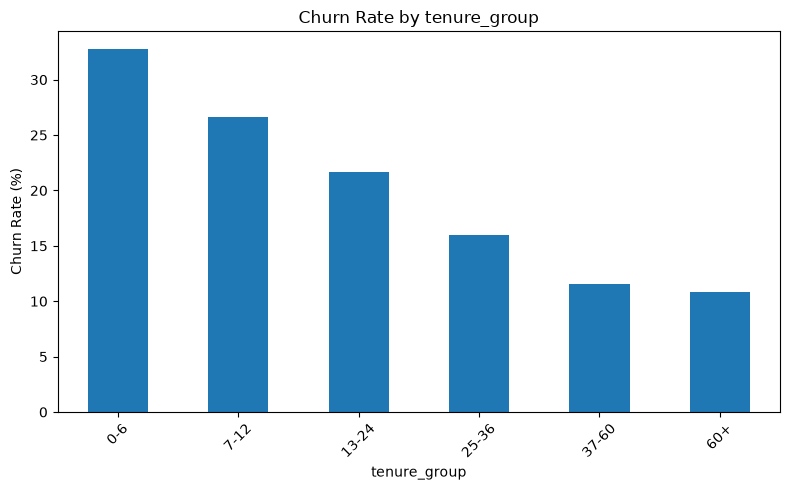

In [38]:
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0, 6, 12, 24, 36, 60, np.inf],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-36",
        "37-60",
        "60+"
    ]
)
plot_churn_by_category(
    df,
    "tenure_group"
)


In [39]:
interaction = (
    df.groupby(
        ["contract_type", "competitor_offer_received"]
    )["churn_binary"]
    .mean()
    .mul(100)
    .reset_index()
)

interaction

,contract_type,competitor_offer_received,churn_binary
0,Annual,False,9.94
1,Annual,True,17.99
2,Month-to-month,False,25.91
3,Month-to-month,True,39.33
4,Two year,False,3.85
5,Two year,True,7.36


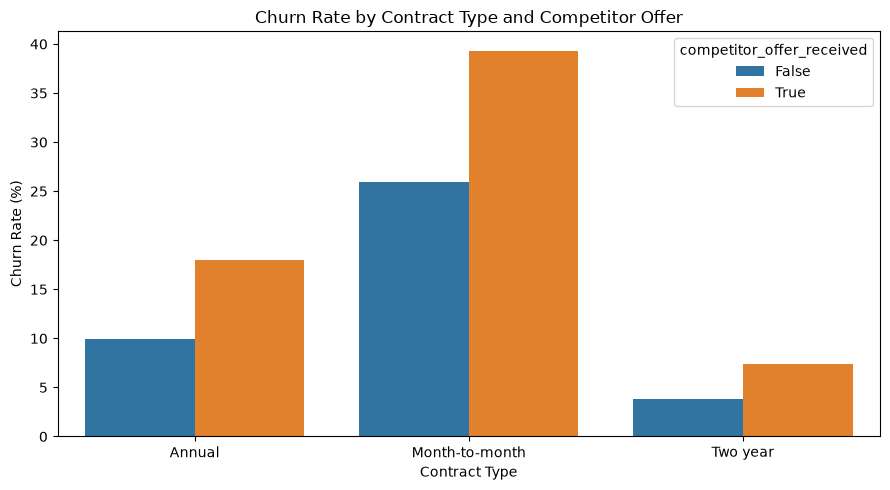

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=interaction,
    x="contract_type",
    y="churn_binary",
    hue="competitor_offer_received"
)

plt.title(
    "Churn Rate by Contract Type and Competitor Offer"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")

plt.tight_layout()
plt.show()

In [41]:
def chi_square_test(data, feature, target="churn"):
    contingency_table = pd.crosstab(
        data[feature],
        data[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    return {
        "feature": feature,
        "chi2": chi2,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    }

In [42]:
chi_results = []

for column in categorical_columns:
    result = chi_square_test(df, column)
    chi_results.append(result)

chi_results = pd.DataFrame(chi_results)

chi_results.sort_values("p_value")

,feature,chi2,p_value,significant_at_0.05
3,contract_type,322.78,0.00,True
7,auto_pay,89.63,0.00,True
9,competitor_offer_received,75.29,0.00,True
8,uses_mobile_app,16.30,0.00,True
4,plan_tier,11.12,0.01,True
2,primary_device,10.84,0.01,True
10,discount_offered,1.66,0.20,False
1,signup_channel,6.20,0.29,False
6,payment_method,5.91,0.32,False
0,service_segment,4.57,0.60,False


In [44]:
from pathlib import Path

Path("../reports").mkdir(
    parents=True,
    exist_ok=True
)

chi_results.to_csv(
    "../reports/categorical_association.csv",
    index=False
)

